In [2]:
# ============================================================
# --- STEP 1: INPUT PARAMETERS ---
# Bottom-Up Company Monte Carlo Simulation
# Primary vs. Secondary PE Fund Comparison
# Quarterly NAV process based on Brown, Ghysels & Gredil (2023)
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. SIMULATION SCALE & TIME GRID
# ------------------------------------------------------------
N_SIMULATIONS = 10_000       # Monte Carlo iterations
RANDOM_SEED   = 42           # For reproducibility

PERIODS_PER_YEAR    = 4
fund_lifetime_years = 10
fund_lifetime_q     = fund_lifetime_years * PERIODS_PER_YEAR  # 40 quarters
investment_period_y = 5
investment_period_q = investment_period_y * PERIODS_PER_YEAR  # 20 quarters

# ------------------------------------------------------------
# 2. GENERAL MARKET ASSUMPTIONS (Quarterly)
# ------------------------------------------------------------
market_return_q_mean = 0.0194  # ~1.94% expected quarterly return (8% annualized)
market_vol_q         = 0.0750  # 7.5% quarterly volatility (15% annualized)

# ------------------------------------------------------------
# 3. FUND ARCHITECTURE
# ------------------------------------------------------------
fund_size = 1.0  # Normalized committed capital

# ------------------------------------------------------------
# 4. PRIMARY FUND — COMPANY-LEVEL ASSUMPTIONS
# ------------------------------------------------------------
mean_n_companies = 12        # Mean number of portfolio companies
sd_n_companies   = 4         # Std dev of portfolio size
min_n_companies  = 5         # Hard floor

# A. Deployment Timing (Front-loaded over 20 quarters)
# Simplified mapping representing: Y1: 25%, Y2: 30%, Y3: 25%, Y4: 15%, Y5: 5%
primary_deploy_weights_q = {}
for q in range(1, 21):
    if q <= 4:   weight = 0.25 / 4
    elif q <= 8: weight = 0.30 / 4
    elif q <= 12: weight = 0.25 / 4
    elif q <= 16: weight = 0.15 / 4
    else:         weight = 0.05 / 4
    primary_deploy_weights_q[q] = weight

# B. Holding Period (Exit Timing)
mean_holding_period_q = 20.0 # Mean 5 years
sd_holding_period_q   = 6.0  # Std dev 1.5 years
min_holding_period_q  = 8.0  # Hard floor: 2 years (no flip sales)

# ------------------------------------------------------------
# 5. SECTOR ALLOCATIONS & PARAMETERS (Quarterly Converted)
# ------------------------------------------------------------
sector_weights = {
    'Technology': 0.25, 'Healthcare': 0.20, 'Consumer Discretionary': 0.18,
    'Industrials': 0.15, 'Financial Services': 0.10, 'Energy & Infra': 0.07,
    'Consumer Staples': 0.05
}

sector_params = {
    'Technology':             {'g_TAM_q': 0.028, 'alpha_q': 0.024, 'sigma_idio_q': 0.100, 'mu_share': 0.02, 'sd_share': 0.01, 'ceiling_share': 0.15},
    'Healthcare':             {'g_TAM_q': 0.017, 'alpha_q': 0.015, 'sigma_idio_q': 0.075, 'mu_share': 0.03, 'sd_share': 0.01, 'ceiling_share': 0.20},
    'Consumer Discretionary': {'g_TAM_q': 0.012, 'alpha_q': 0.017, 'sigma_idio_q': 0.090, 'mu_share': 0.04, 'sd_share': 0.02, 'ceiling_share': 0.25},
    'Industrials':            {'g_TAM_q': 0.010, 'alpha_q': 0.010, 'sigma_idio_q': 0.060, 'mu_share': 0.05, 'sd_share': 0.02, 'ceiling_share': 0.30},
    'Financial Services':     {'g_TAM_q': 0.012, 'alpha_q': 0.012, 'sigma_idio_q': 0.075, 'mu_share': 0.03, 'sd_share': 0.015, 'ceiling_share': 0.20},
    'Energy & Infra':         {'g_TAM_q': 0.007, 'alpha_q': 0.007, 'sigma_idio_q': 0.060, 'mu_share': 0.06, 'sd_share': 0.02, 'ceiling_share': 0.35},
    'Consumer Staples':       {'g_TAM_q': 0.007, 'alpha_q': 0.005, 'sigma_idio_q': 0.050, 'mu_share': 0.05, 'sd_share': 0.015, 'ceiling_share': 0.30},
}

# ------------------------------------------------------------
# 6. SECONDARY FUND — TRANSACTION PARAMETERS
# ------------------------------------------------------------
# A. Entry Timing
sec_entry_mean_q = 20.0  # Mean Quarter 20 (Year 5)
sec_entry_sd_q   = 4.0   # Std dev of 4 quarters
sec_entry_min_q  = 16.0  # Hard floor: Quarter 16 (Year 4)
sec_entry_max_q  = 36.0  # Hard ceiling: Quarter 36 (Year 9)

# B. NAV Discount
sec_discount_mean = 0.15  # 15% mean discount
sec_discount_sd   = 0.025 # 2.5% standard deviation
sec_discount_min  = 0.10  # Hard floor: 10% minimum discount
sec_discount_max  = 0.20  # Hard ceiling: 20% maximum discount

# ------------------------------------------------------------
# 7. NAV REPORTING & SMOOTHING (Brown et al. 2023)
# ------------------------------------------------------------
lambda_q    = 0.50  # GP appraisal smoothing weight (Quarterly approx of BGG 0.951 weekly)
sigma_noise = 0.05  # Random NAV reporting noise std dev

# ------------------------------------------------------------
# VALIDATION DASHBOARD
# ------------------------------------------------------------
assert abs(sum(primary_deploy_weights_q.values()) - 1.0) < 1e-9, "Deployment weights must sum to 1"
assert abs(sum(sector_weights.values()) - 1.0) < 1e-9, "Sector weights must sum to 1"
assert min_n_companies >= 1
assert sec_entry_min_q < sec_entry_max_q
assert sec_discount_min < sec_discount_max
assert 0 < lambda_q < 1

print("=" * 65)
print(" STEP 1: PARAMETERS LOADED — Stochastic Model, BGG-calibrated")
print("=" * 65)
print(f"  Simulations:           {N_SIMULATIONS:,}")
print(f"  Time grid:             {fund_lifetime_q} quarters ({fund_lifetime_years} years)")
print(f"  Secondary entry:       Probabilistic (Bounds: Q{int(sec_entry_min_q)} to Q{int(sec_entry_max_q)})")
print(f"  Secondary discount:    Probabilistic (Bounds: {sec_discount_min:.0%} to {sec_discount_max:.0%})")
print("=" * 65)

 STEP 1: PARAMETERS LOADED — Stochastic Model, BGG-calibrated
  Simulations:           10,000
  Time grid:             40 quarters (10 years)
  Secondary entry:       Probabilistic (Bounds: Q16 to Q36)
  Secondary discount:    Probabilistic (Bounds: 10% to 20%)


In [3]:
# ============================================================
# --- STEP 2: BOTTOM-UP CASH FLOW & NAV ENGINE ---
# Generates N_SIMULATIONS funds: company-level GBM paths,
# fund-level cash flows + true NAV, BGG (2023) appraisal
# smoothing on cumulative log-returns, and the secondary
# buyer's CF stream.
# ============================================================

import time
import numpy as np

print("Step 2: Bottom-Up Simulation Engine")
t0 = time.time()

# ------------------------------------------------------------
# A. STORAGE ARRAYS (rows = simulations, cols = quarters 0..40)
# ------------------------------------------------------------
prim_calls_arr    = np.zeros((N_SIMULATIONS, fund_lifetime_q + 1))  # stored NEGATIVE
prim_dists_arr    = np.zeros((N_SIMULATIONS, fund_lifetime_q + 1))  # stored POSITIVE
true_nav_arr      = np.zeros((N_SIMULATIONS, fund_lifetime_q + 1))  # underlying value
rep_nav_arr       = np.zeros((N_SIMULATIONS, fund_lifetime_q + 1))  # BGG-smoothed NAV

# Internal AR(1) state of the smoother — kept for diagnostics & robustness
r_true_period_arr = np.zeros((N_SIMULATIONS, fund_lifetime_q + 1))  # CF-adjusted true return
r_bar_period_arr  = np.zeros((N_SIMULATIONS, fund_lifetime_q + 1))  # smoothed periodic return

# Secondary buyer
sec_cf_arr        = np.zeros((N_SIMULATIONS, fund_lifetime_q + 1))  # buyer's net CFs
sec_metadata      = np.zeros((N_SIMULATIONS, 2))                    # [entry_q, discount]

# ------------------------------------------------------------
# B. PRE-COMPUTE LOOKUPS (so np.random.choice is fast)
# ------------------------------------------------------------
sector_names = list(sector_weights.keys())
sector_probs = np.array(list(sector_weights.values()))
deploy_qs    = np.array(list(primary_deploy_weights_q.keys()))
deploy_probs = np.array(list(primary_deploy_weights_q.values()))

# Modern numpy Generator — self-contained, no global state
rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------------------
# C. MAIN MONTE CARLO LOOP
# ------------------------------------------------------------
for sim in range(N_SIMULATIONS):

    if (sim + 1) % 2000 == 0:
        print(f"  ... {sim + 1:,} / {N_SIMULATIONS:,}")

    # --- (1) Fund-level setup ---
    n_companies = int(max(min_n_companies,
                          np.round(rng.normal(mean_n_companies, sd_n_companies))))
    capital_per_company = fund_size / n_companies

    fund_true_nav = np.zeros(fund_lifetime_q + 1)

    # --- (2) Build each company's value path and book it ---
    for c in range(n_companies):

        # Sector and growth parameters
        sector = rng.choice(sector_names, p=sector_probs)
        params = sector_params[sector]

        # Investment quarter (drawn from staged deployment curve)
        invest_q = int(rng.choice(deploy_qs, p=deploy_probs))

        # Holding period: drawn, clipped to floor, capped at fund liquidation
        hold_q = int(max(min_holding_period_q,
                         np.round(rng.normal(mean_holding_period_q,
                                             sd_holding_period_q))))
        exit_q  = int(min(fund_lifetime_q, invest_q + hold_q))
        periods = exit_q - invest_q

        if periods <= 0:
            continue   # no time to hold — skip (avoids leaking a capital call)

        # Sector-driven quarterly drift via market-share saturation
        mkt_share   = np.clip(rng.normal(params['mu_share'], params['sd_share']),
                              0.001, params['ceiling_share'])
        penetration = mkt_share / params['ceiling_share']
        drift       = params['g_TAM_q'] + params['alpha_q'] * (1 - penetration)
        sigma       = params['sigma_idio_q']

        # GBM company value path (log-normal). The k-th element is the value
        # at quarter invest_q + k + 1, i.e. values[-1] is the value at exit_q.
        shocks      = rng.normal(0, sigma, periods)
        log_returns = drift - 0.5 * sigma**2 + shocks
        values      = capital_per_company * np.exp(np.cumsum(log_returns))

        # --- Bookkeeping (symmetric at investment and exit) ---
        prim_calls_arr[sim, invest_q] -= capital_per_company       # cash call (outflow)
        fund_true_nav[invest_q]       += capital_per_company       # asset on books at face value
        if periods > 1:
            fund_true_nav[invest_q + 1 : exit_q] += values[:-1]    # holding-period NAV
        prim_dists_arr[sim, exit_q]   += values[-1]                # exit value distributed
        # NB: fund_true_nav[exit_q] does NOT include this company — it has been sold

    true_nav_arr[sim] = fund_true_nav

    # --- (3) BGG (2023) appraisal smoothing on cumulative log-returns ---
    # State equation (cumulative form):
    #     r_bar_{0:t} = (1 - lambda) r_{0:t} + lambda r_bar_{0:t-1}
    # Reported NAV:
    #     log NAV_rep_t = log V_t + (r_bar_{0:t} - r_{0:t}) + n_t,   n_t ~ N(0, sigma_n^2)
    fund_rep_nav = np.zeros(fund_lifetime_q + 1)
    r_cum     = 0.0    # true cumulative log-return
    r_bar_cum = 0.0    # smoothed cumulative log-return

    for t in range(1, fund_lifetime_q + 1):
        denom = fund_true_nav[t - 1]
        # CF-adjusted period log-return: (V_t + D_t - C_paid_t) / V_{t-1}
        # Calls stored as negative, so "subtract paid call" = "add stored value"
        numer = fund_true_nav[t] + prim_dists_arr[sim, t] + prim_calls_arr[sim, t]

        if denom > 1e-9 and numer > 1e-9:
            r_t = np.log(numer / denom)
        else:
            r_t = 0.0   # fund not active this quarter; smoother carries forward

        r_cum_new     = r_cum + r_t
        r_bar_cum_new = lambda_q * r_bar_cum + (1 - lambda_q) * r_cum_new

        # Capture periodic returns (diagnostic / robustness use)
        r_true_period_arr[sim, t] = r_t
        r_bar_period_arr[sim, t]  = r_bar_cum_new - r_bar_cum

        if fund_true_nav[t] > 1e-9:
            noise = rng.normal(0, sigma_noise)
            fund_rep_nav[t] = fund_true_nav[t] * np.exp((r_bar_cum_new - r_cum_new) + noise)
        else:
            fund_rep_nav[t] = 0.0

        r_cum     = r_cum_new
        r_bar_cum = r_bar_cum_new

    rep_nav_arr[sim] = fund_rep_nav

    # --- (4) Secondary buyer's CF stream ---
    entry_q = int(np.round(np.clip(
                    rng.normal(sec_entry_mean_q, sec_entry_sd_q),
                    sec_entry_min_q, sec_entry_max_q)))
    discount = float(np.clip(
                    rng.normal(sec_discount_mean, sec_discount_sd),
                    sec_discount_min, sec_discount_max))

    sec_metadata[sim, 0] = entry_q
    sec_metadata[sim, 1] = discount

    # Buyer pays (1 - d) * REPORTED NAV at entry; inherits subsequent calls and distributions
    purchase_price = fund_rep_nav[entry_q] * (1 - discount)
    sec_cf_arr[sim, entry_q] -= purchase_price
    if entry_q < fund_lifetime_q:
        sec_cf_arr[sim, entry_q + 1:] += prim_calls_arr[sim, entry_q + 1:]
        sec_cf_arr[sim, entry_q + 1:] += prim_dists_arr[sim, entry_q + 1:]

# ------------------------------------------------------------
# D. COMPLETION
# ------------------------------------------------------------
elapsed = time.time() - t0
print("=" * 65)
print(" STEP 2 COMPLETE: DATA MATRICES GENERATED")
print("=" * 65)
print(f"  Total compute time:      {elapsed:.1f} seconds")
print(f"  Primary calls shape:     {prim_calls_arr.shape}")
print(f"  Primary dists shape:     {prim_dists_arr.shape}")
print(f"  True NAV shape:          {true_nav_arr.shape}")
print(f"  Reported NAV shape:      {rep_nav_arr.shape}")
print(f"  Secondary CF shape:      {sec_cf_arr.shape}")
print("=" * 65)

# ------------------------------------------------------------
# E. VALIDATION DIAGNOSTICS
# ------------------------------------------------------------

# (i) BGG smoothing validation: autocorrelation of periodic log-returns
def autocorr1_panel(series, q_lo=4, q_hi=37):
    """Per-fund lag-1 autocorrelation, restricted to the mid-fund active window."""
    rho = []
    for s in range(series.shape[0]):
        r = series[s, q_lo:q_hi]
        if r.std() > 1e-9 and len(r) > 4:
            x = r[:-1] - r[:-1].mean()
            y = r[1:]  - r[1:].mean()
            denom = np.sqrt((x * x).sum() * (y * y).sum())
            if denom > 0:
                rho.append((x * y).sum() / denom)
    return np.array(rho)

rho_true = autocorr1_panel(r_true_period_arr)
rho_bar  = autocorr1_panel(r_bar_period_arr)

print(f"\n  Smoothing validation — periodic log-return autocorrelation (Q4..Q36):")
print(f"    r_t (true, i.i.d. by construction):  rho_1 = {rho_true.mean():+.3f}   (target ~0)")
print(f"    r_bar_t (smoothed):                  rho_1 = {rho_bar.mean():+.3f}   (target ~{lambda_q:.2f}; BGG empirical 0.41)")

# (ii) Year-end averages — should show classic primary-fund pattern
mean_true       = true_nav_arr.mean(axis=0)
mean_rep        = rep_nav_arr.mean(axis=0)
mean_cum_called = prim_calls_arr.cumsum(axis=1).mean(axis=0)
mean_cum_dist   = prim_dists_arr.cumsum(axis=1).mean(axis=0)

print(f"\n  Year-end averages:")
print(f"  {'Y':>3} {'NAV_true':>10} {'NAV_rep':>10} {'Cum.Called':>12} {'Cum.Dist':>10}")
for y in [0, 1, 2, 3, 5, 7, 10]:
    q = y * 4
    print(f"  {y:>3} {mean_true[q]:>10.4f} {mean_rep[q]:>10.4f} "
          f"{-mean_cum_called[q]:>12.4f} {mean_cum_dist[q]:>10.4f}")

# (iii) Headline multiples
final_value  = prim_dists_arr.sum(axis=1) + true_nav_arr[:, -1]
final_called = -prim_calls_arr.sum(axis=1)
TVPI         = final_value / final_called

print(f"\n  Terminal TVPI: mean {TVPI.mean():.2f}x, median {np.median(TVPI):.2f}x, "
      f"P10 {np.percentile(TVPI, 10):.2f}x, P90 {np.percentile(TVPI, 90):.2f}x")

Step 2: Bottom-Up Simulation Engine
  ... 2,000 / 10,000
  ... 4,000 / 10,000
  ... 6,000 / 10,000
  ... 8,000 / 10,000
  ... 10,000 / 10,000
 STEP 2 COMPLETE: DATA MATRICES GENERATED
  Total compute time:      17.4 seconds
  Primary calls shape:     (10000, 41)
  Primary dists shape:     (10000, 41)
  True NAV shape:          (10000, 41)
  Reported NAV shape:      (10000, 41)
  Secondary CF shape:      (10000, 41)

  Smoothing validation — periodic log-return autocorrelation (Q4..Q36):
    r_t (true, i.i.d. by construction):  rho_1 = -0.013   (target ~0)
    r_bar_t (smoothed):                  rho_1 = +0.442   (target ~0.50; BGG empirical 0.41)

  Year-end averages:
    Y   NAV_true    NAV_rep   Cum.Called   Cum.Dist
    0     0.0000     0.0000      -0.0000     0.0000
    1     0.2631     0.2577       0.2515     0.0000
    2     0.6111     0.5939       0.5518     0.0000
    3     0.9333     0.9066       0.8007     0.0163
    5     1.1933     1.1570       1.0000     0.2291
    7     0

In [33]:
# ============================================================
# --- STEP 3: PERFORMANCE METRICS & THE REVERTED J-CURVE ---
# Calculates Pooled IRR, TVPI, DPI and plots the hypothesis
# ============================================================

import numpy_financial as npf
import matplotlib.pyplot as plt

print("Calculating Pooled Cash Flows and IRRs...")

# ------------------------------------------------------------
# 1. PRIMARY FUND POOLED PERFORMANCE
# ------------------------------------------------------------
# Average across all 10,000 funds
avg_prim_calls = np.mean(prim_calls_arr, axis=0)
avg_prim_dists = np.mean(prim_dists_arr, axis=0)
avg_rep_nav    = np.mean(rep_nav_arr, axis=0)

primary_j_curve_irr = []
primary_tvpi        = []
primary_dpi         = []

for t in range(1, fund_lifetime_q + 1):
    # Slice cash flows from Q0 up to Qt
    cf_t = avg_prim_calls[:t+1] + avg_prim_dists[:t+1]
    
    # TVPI & DPI Math
    cum_calls = abs(np.sum(avg_prim_calls[:t+1]))
    cum_dists = np.sum(avg_prim_dists[:t+1])
    
    if cum_calls > 0:
        primary_dpi.append(cum_dists / cum_calls)
        primary_tvpi.append((cum_dists + avg_rep_nav[t]) / cum_calls)
    else:
        primary_dpi.append(0)
        primary_tvpi.append(0)
        
    # IRR Math: Add the current NAV as the terminal liquidating value
    cf_t_irr = cf_t.copy()
    cf_t_irr[-1] += avg_rep_nav[t]
    
    irr_q = npf.irr(cf_t_irr)
    
    # Convert quarterly IRR to Annualized IRR
    if irr_q is None or np.isnan(irr_q):
        primary_j_curve_irr.append(np.nan)
    else:
        primary_j_curve_irr.append((1 + irr_q)**4 - 1)

# ------------------------------------------------------------
# 2. SECONDARY FUND POOLED PERFORMANCE (Year 5 Entry Subset)
# ------------------------------------------------------------
# To plot a clean line, we filter for Secondary funds that entered around Year 5 (Q19 to Q21)
year_5_mask = (sec_metadata[:, 0] >= 19) & (sec_metadata[:, 0] <= 21)
sec_cf_subset = sec_cf_arr[year_5_mask]

avg_sec_cf = np.mean(sec_cf_subset, axis=0)
# The Reported NAV acts as the terminal value for the secondary buyer too
avg_sec_nav = np.mean(rep_nav_arr[year_5_mask], axis=0) 

secondary_j_curve_irr = [np.nan] * 20 # Empty for the first 5 years (Buyer hasn't entered)

# Calculate Secondary IRR from Quarter 21 to 40
for t in range(21, fund_lifetime_q + 1):
    # Secondary CFs up to quarter t
    cf_t = avg_sec_cf[:t+1].copy()
    cf_t[-1] += avg_sec_nav[t]
    
    irr_q = npf.irr(cf_t)
    
    if irr_q is None or np.isnan(irr_q):
        secondary_j_curve_irr.append(np.nan)
    else:
        secondary_j_curve_irr.append((1 + irr_q)**4 - 1)

# ------------------------------------------------------------
# 3. PLOT THE REVERTED J-CURVE (Study I Hypothesis)
# ------------------------------------------------------------
quarters = np.arange(1, 41)
years = quarters / 4

plt.figure(figsize=(12, 7))

# Plot Primary J-Curve
plt.plot(years, [irr * 100 if not np.isnan(irr) else 0 for irr in primary_j_curve_irr], 
         label="Primary Fund IRR (Classic J-Curve)", color='darkblue', linewidth=3)

# Plot Secondary J-Curve (starts at Year 5)
plt.plot(years, [irr * 100 if not np.isnan(irr) else np.nan for irr in secondary_j_curve_irr], 
         label="Secondary Fund IRR (Reverted J-Curve)", color='darkorange', linewidth=3, linestyle='--')

plt.axhline(0, color='black', linewidth=1)
plt.axvline(5, color='gray', linestyle=':', label='Secondary Entry (Year 5)')

plt.title("Study I Validation: The Reverted J-Curve", fontsize=16, fontweight='bold')
plt.xlabel("Fund Age (Years)", fontsize=12)
plt.ylabel("Since-Inception Annualized IRR (%)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(-110, 150) # Standard PE return bounds

plt.tight_layout()
plt.show()

print("Step 3 Complete. Chart Generated.")

Calculating Pooled Cash Flows and IRRs...


c:\Users\Gianni\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Gianni\anaconda3\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


LinAlgError: Array must not contain infs or NaNs

Running the Implied Discount Estimator on 10,000 funds...


C:\Users\Gianni\AppData\Local\Temp\ipykernel_15060\3345659278.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(['{:,.0%}'.format(x) for x in vals_x])
C:\Users\Gianni\AppData\Local\Temp\ipykernel_15060\3345659278.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0%}'.format(x) for x in vals_y])


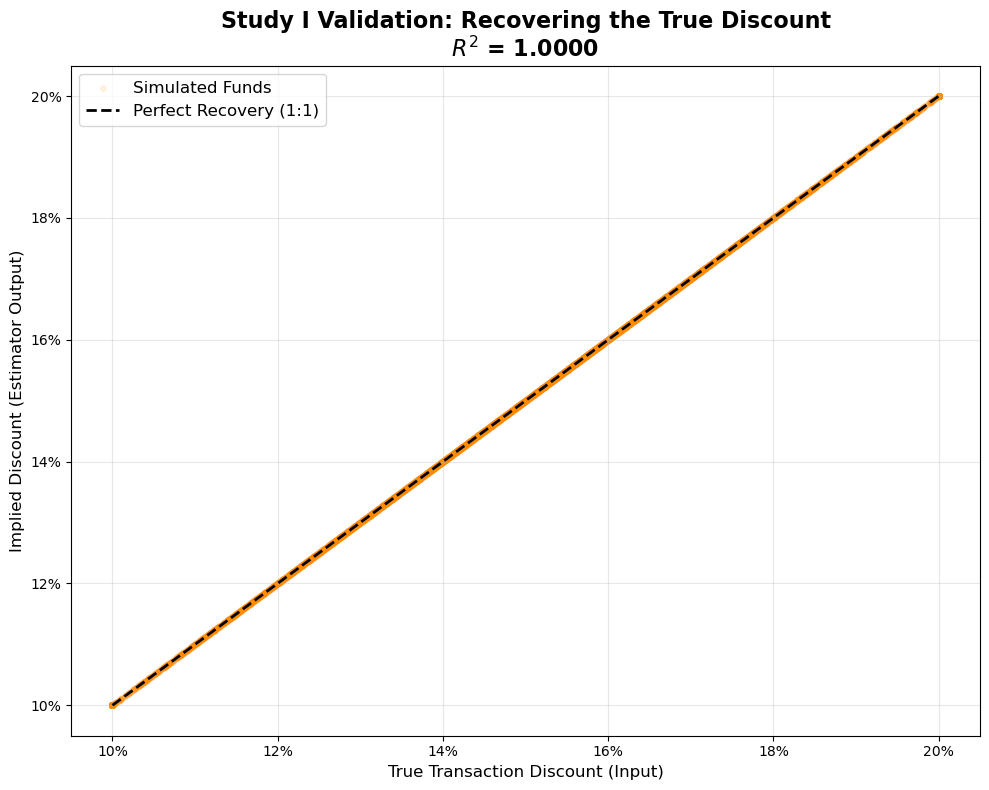

Closed-Loop Check Successful. Estimator Accuracy (R-squared): 100.00%


In [ ]:
# ============================================================
# --- STEP 4: THE IMPLIED DISCOUNT ESTIMATOR ---
# Validating the Closed-Loop Check (Study I)
# ============================================================

import matplotlib.pyplot as plt
from scipy import stats

print("Running the Implied Discount Estimator on 10,000 funds...")

implied_discounts = []
true_discounts = []

for sim in range(N_SIMULATIONS):
    entry_q = int(sec_metadata[sim, 0])
    true_d  = sec_metadata[sim, 1]
    
    # 1. Gather the observable data from Quarter T onwards
    nav_t = rep_nav_arr[sim, entry_q]
    
    # Skip edge cases where NAV is basically zero (causes division by zero errors)
    if nav_t < 0.05:
        continue
        
    future_calls = abs(np.sum(prim_calls_arr[sim, entry_q + 1:]))
    future_dists = np.sum(prim_dists_arr[sim, entry_q + 1:])
    
    # Total Value includes any final liquidating NAV at Q40
    total_future_value = future_dists + rep_nav_arr[sim, -1] 
    
    # 2. Calculate the observable TVPIs
    # Primary TVPI from Quarter T
    cost_basis_prim = future_calls + nav_t
    tvpi_prim = total_future_value / cost_basis_prim if cost_basis_prim > 0 else 0
    
    # Secondary TVPI from Quarter T
    cost_basis_sec = future_calls + (nav_t * (1 - true_d))
    tvpi_sec = total_future_value / cost_basis_sec if cost_basis_sec > 0 else 0
    
    # 3. Apply Simon's Estimator Formula
    if tvpi_sec > 0 and tvpi_prim > 0:
        c = future_calls / nav_t
        d_implied = (c + 1) * (1 - (tvpi_prim / tvpi_sec))
        
        implied_discounts.append(d_implied)
        true_discounts.append(true_d)

# Calculate the R-squared to prove the estimator's accuracy
slope, intercept, r_value, p_value, std_err = stats.linregress(true_discounts, implied_discounts)
r_squared = r_value**2

# ------------------------------------------------------------
# PLOT THE VALIDATION RESULTS
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))

# Plot the 10,000 data points
plt.scatter(true_discounts, implied_discounts, alpha=0.1, color='darkorange', s=15, label='Simulated Funds')

# Plot the Perfect Accuracy Line (45-degree angle)
ideal_line = [min(true_discounts), max(true_discounts)]
plt.plot(ideal_line, ideal_line, color='black', linewidth=2, linestyle='--', label='Perfect Recovery (1:1)')

# Formatting
plt.title(f"Study I Validation: Recovering the True Discount\n$R^2$ = {r_squared:.4f}", fontsize=16, fontweight='bold')
plt.xlabel("True Transaction Discount (Input)", fontsize=12)
plt.ylabel("Implied Discount (Estimator Output)", fontsize=12)

# Convert axes to percentages
vals_x = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:,.0%}'.format(x) for x in vals_x])
vals_y = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0%}'.format(x) for x in vals_y])

plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Closed-Loop Check Successful. Estimator Accuracy (R-squared): {r_squared:.2%}")